## Use MSK-MET data to get frequency of metastasis to anatomical sites by primary cancer type

In [3]:
import os
import csv
data_dir = "/data/morrisq/divyak/projects/metient/data"
# Downloaded from https://www.cbioportal.org/study/summary?id=msk_met_2021
mks_met_csv_fn = os.path.join(data_dir, "msk_met","msk_met_2021_clinical_data.tsv")


In [4]:
import pandas as pd
msk_met_df = pd.read_csv(mks_met_csv_fn, sep = '\t')
msk_met_df

,Study ID,Patient ID,Sample ID,Age at Death,Age at First Mets Dx,Age at Last Contact,Age at Sequencing,Age at Surgical Procedure,Cancer Type,Cancer Type Detailed,...,Primary Tumor Site,Race Category,Number of Samples Per Patient,Sample coverage,Sample Type,Sex,Subtype,Subtype Abbreviation,TMB (nonsynonymous),Tumor Purity
0,msk_met_2021,P-0000004,P-0000004-T01-IM3,40.06,39.66,NaN,39.74,37.03,Breast Cancer,Breast Invasive Ductal Carcinoma,...,Breast,White,1,428,Primary,Female,Breast Ductal HR+HER2-,IDC HR+HER2-,4.436621,50.0
1,msk_met_2021,P-0000015,P-0000015-T01-IM3,45.60,44.25,NaN,44.44,44.42,Breast Cancer,Breast Invasive Ductal Carcinoma,...,Breast,White,1,281,Metastasis,Female,Breast Ductal HR+HER2-,IDC HR+HER2-,7.764087,40.0
2,msk_met_2021,P-0000024,P-0000024-T01-IM3,64.25,59.44,NaN,61.33,61.00,Endometrial Cancer,Uterine Endometrioid Carcinoma,...,Uterus,White,1,1016,Metastasis,Female,Uterine Endometrioid,UCEC ENDO,6.654932,40.0
3,msk_met_2021,P-0000025,P-0000025-T02-IM5,76.53,69.65,NaN,74.81,74.64,Endometrial Cancer,Uterine Serous Carcinoma/Uterine Papillary Ser...,...,Uterus,White,1,1147,Metastasis,Female,Uterine Serous,UCEC SEROUS,1.957439,30.0
4,msk_met_2021,P-0000026,P-0000026-T01-IM3,NaN,68.41,78.43,71.72,71.58,Endometrial Cancer,Uterine Endometrioid Carcinoma,...,Uterus,Asian-far east/indian subcont,1,1222,Metastasis,Female,Uterine Endometrioid,UCEC ENDO,4.436621,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25770,msk_met_2021,P-0050559,P-0050559-T01-IM6,NaN,NaN,58.12,57.23,56.38,Bladder Cancer,Bladder Urothelial Carcinoma,...,Bladder,White,1,836,Primary,Male,Bladder Urothelial,BLCA,12.105773,10.0
25771,msk_met_2021,P-0050565,P-0050565-T01-IM6,NaN,70.00,71.03,70.14,70.00,Non-Small Cell Lung Cancer,Lung Squamous Cell Carcinoma,...,Lung,White,1,809,Metastasis,Female,Lung Squamous Cell Carcinoma,LUSC,10.376377,20.0
25772,msk_met_2021,P-0050566,P-0050566-T01-IM6,NaN,80.84,81.76,80.88,80.79,Endometrial Cancer,Uterine Carcinosarcoma/Uterine Malignant Mixed...,...,Uterus,White,1,633,Primary,Female,Uterine Carcinosarcoma,UCEC CSRC,9.511679,50.0
25773,msk_met_2021,P-0050567,P-0050567-T01-IM6,NaN,NaN,44.11,43.23,43.21,Colorectal Cancer,Rectal Adenocarcinoma,...,Colon,White,1,809,Primary,Male,Colorectal MSS,CRC MSS,6.917585,30.0


In [5]:
cols_to_keep = ["Cancer Type"] + [x for x in list(msk_met_df.columns) if "Distant Mets:" in x]
msk_met_df = msk_met_df[cols_to_keep]
msk_met_df = msk_met_df.replace(to_replace = ['Yes','No'],value = [1,0])
msk_met_df

,Cancer Type,Distant Mets: Adrenal Gland,Distant Mets: Biliary tract,Distant Mets: Bladder/UT,Distant Mets: Bone,Distant Mets: Bowel,Distant Mets: Breast,Distant Mets: CNS/Brain,Distant Mets: Distant LN,Distant Mets: Female Genital,...,Distant Mets: Kidney,Distant Mets: Liver,Distant Mets: Lung,Distant Mets: Male Genital,Distant Mets: Mediastinum,Distant Mets: Ovary,Distant Mets: Pleura,Distant Mets: PNS,Distant Mets: Skin,Distant Mets: Unspecified
0,Breast Cancer,0,0,0,1,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
1,Breast Cancer,0,0,0,1,0,0,1,1,0,...,0,1,1,0,0,1,1,0,0,1
2,Endometrial Cancer,0,0,0,1,0,0,0,0,0,...,0,1,1,0,0,0,0,0,0,1
3,Endometrial Cancer,1,1,0,0,1,0,0,0,1,...,0,1,0,0,0,1,0,0,0,1
4,Endometrial Cancer,0,0,0,0,1,0,0,1,1,...,0,1,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25770,Bladder Cancer,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
25771,Non-Small Cell Lung Cancer,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
25772,Endometrial Cancer,0,0,0,0,1,0,0,0,0,...,0,1,0,0,0,0,0,0,0,1
25773,Colorectal Cancer,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [7]:
summed_df = msk_met_df.groupby("Cancer Type").sum()
summed_df.columns = [x.replace("Distant Mets: ", "") for x in list(summed_df.columns)]
summed_df.to_csv(os.path.join(data_dir,  "msk_met","msk_met_freq_by_cancer_type.csv"))
summed_df

,Adrenal Gland,Biliary tract,Bladder/UT,Bone,Bowel,Breast,CNS/Brain,Distant LN,Female Genital,Head and Neck,...,Kidney,Liver,Lung,Male Genital,Mediastinum,Ovary,Pleura,PNS,Skin,Unspecified
Cancer Type,,,,,,,,,,,,,,,,,,,,,
Anal Cancer,1,4,7,15,15,0,6,35,13,0,...,1,37,34,11,3,0,7,1,5,44
Appendiceal Cancer,6,68,40,17,123,0,2,18,63,1,...,3,89,25,5,1,63,17,1,13,168
Bladder Cancer,43,31,317,249,80,6,47,385,39,6,...,83,196,242,124,12,9,48,41,22,763
Breast Cancer,111,106,50,1277,76,171,435,872,94,20,...,49,945,609,1,80,99,376,284,409,1323
Cervical Cancer,3,3,23,15,21,0,5,49,49,1,...,5,26,29,0,5,7,10,6,2,64
Colorectal Cancer,182,273,226,504,611,12,165,681,276,19,...,64,2026,1410,136,27,239,212,150,94,2620
Endometrial Cancer,39,85,162,142,237,6,53,397,502,4,...,24,282,260,0,8,166,89,30,34,714
Esophagogastric Cancer,86,183,30,199,82,4,65,185,27,16,...,16,347,192,10,23,46,77,48,24,513
Gastrointestinal Neuroendocrine Tumor,0,3,3,23,8,2,1,13,2,0,...,0,94,9,0,0,2,2,1,5,105


In [8]:
# Normalize
row_sums = summed_df.sum(axis=1)
print(row_sums)
freq_df = summed_df.div(row_sums, axis=0)
freq_df

Cancer Type
Anal Cancer                                256
Appendiceal Cancer                         890
Bladder Cancer                            2896
Breast Cancer                             7643
Cervical Cancer                            349
Colorectal Cancer                        11198
Endometrial Cancer                        3706
Esophagogastric Cancer                    2531
Gastrointestinal Neuroendocrine Tumor      314
Gastrointestinal Stromal Tumor             647
Germ Cell Tumor                           1097
Head and Neck Cancer                      1349
Hepatobiliary Cancer                      2349
Melanoma                                  3241
Mesothelioma                               544
Non-Small Cell Lung Cancer               13151
Ovarian Cancer                            6681
Pancreatic Cancer                         5831
Prostate Cancer                           5352
Renal Cell Carcinoma                      1617
Salivary Gland Cancer                      617
S

,Adrenal Gland,Biliary tract,Bladder/UT,Bone,Bowel,Breast,CNS/Brain,Distant LN,Female Genital,Head and Neck,...,Kidney,Liver,Lung,Male Genital,Mediastinum,Ovary,Pleura,PNS,Skin,Unspecified
Cancer Type,,,,,,,,,,,,,,,,,,,,,
Anal Cancer,0.003906,0.015625,0.027344,0.058594,0.058594,0.000000,0.023438,0.136719,0.050781,0.000000,...,0.003906,0.144531,0.132812,0.042969,0.011719,0.000000,0.027344,0.003906,0.019531,0.171875
Appendiceal Cancer,0.006742,0.076404,0.044944,0.019101,0.138202,0.000000,0.002247,0.020225,0.070787,0.001124,...,0.003371,0.100000,0.028090,0.005618,0.001124,0.070787,0.019101,0.001124,0.014607,0.188764
Bladder Cancer,0.014848,0.010704,0.109461,0.085981,0.027624,0.002072,0.016229,0.132942,0.013467,0.002072,...,0.028660,0.067680,0.083564,0.042818,0.004144,0.003108,0.016575,0.014157,0.007597,0.263467
Breast Cancer,0.014523,0.013869,0.006542,0.167081,0.009944,0.022373,0.056915,0.114091,0.012299,0.002617,...,0.006411,0.123643,0.079681,0.000131,0.010467,0.012953,0.049195,0.037158,0.053513,0.173100
Cervical Cancer,0.008596,0.008596,0.065903,0.042980,0.060172,0.000000,0.014327,0.140401,0.140401,0.002865,...,0.014327,0.074499,0.083095,0.000000,0.014327,0.020057,0.028653,0.017192,0.005731,0.183381
Colorectal Cancer,0.016253,0.024379,0.020182,0.045008,0.054563,0.001072,0.014735,0.060814,0.024647,0.001697,...,0.005715,0.180925,0.125915,0.012145,0.002411,0.021343,0.018932,0.013395,0.008394,0.233970
Endometrial Cancer,0.010523,0.022936,0.043713,0.038316,0.063950,0.001619,0.014301,0.107124,0.135456,0.001079,...,0.006476,0.076093,0.070157,0.000000,0.002159,0.044792,0.024015,0.008095,0.009174,0.192661
Esophagogastric Cancer,0.033979,0.072303,0.011853,0.078625,0.032398,0.001580,0.025682,0.073094,0.010668,0.006322,...,0.006322,0.137100,0.075859,0.003951,0.009087,0.018175,0.030423,0.018965,0.009482,0.202687
Gastrointestinal Neuroendocrine Tumor,0.000000,0.009554,0.009554,0.073248,0.025478,0.006369,0.003185,0.041401,0.006369,0.000000,...,0.000000,0.299363,0.028662,0.000000,0.000000,0.006369,0.006369,0.003185,0.015924,0.334395


In [10]:
freq_df.to_csv(os.path.join(data_dir, "msk_met", "msk_met_freq_by_cancer_type_normalized.csv"))

## MSK-CHORD timing analysis


In [14]:

from scipy.stats import spearmanr
timeline_df = pd.read_csv('/data/morrisq/divyak/data/data_timeline_tumor_sites.txt', delimiter = '\t')

# Downloaded from https://www.cbioportal.org/study/summary?id=msk_chord_2024
patient_df = pd.read_csv(os.path.join(data_dir,"msk_met",'msk_chord_2024_clinical_data.tsv'), delimiter = '\t')
patient_df = patient_df.rename(columns={'Patient ID': 'PATIENT_ID'})

# Merge patient cancer type info with timeline data
timeline_df = pd.merge(
    timeline_df,
    patient_df[['PATIENT_ID', 'Cancer Type', 'Cancer Type Detailed']], 
    on='PATIENT_ID',
    how='left',
    suffixes=('_timeline', '_patient')
)
timeline_df = timeline_df[~timeline_df['Cancer Type'].isna()]
print(len(timeline_df))

# Sort timeline by patient and start date, then get ordered tumor sites per patient
ordered_sites = (timeline_df
    .sort_values(['PATIENT_ID', 'START_DATE'])
    .groupby('PATIENT_ID')
    .agg({'TUMOR_SITE': lambda x: [site for site in list(dict.fromkeys(x)) if site != 'No Tumor Sites']})  # Remove duplicates while maintaining order and filter out "No Tumor Sites"
    .reset_index()
)

# Rename column to be more descriptive
ordered_sites = ordered_sites.rename(columns={'TUMOR_SITE': 'ordered_tumor_sites'})

print(ordered_sites.head())

# Create cancer type by tumor site matrix
# Get tumor site columns and clean up names
tumor_site_cols = [col for col in patient_df.columns if col.startswith('Tumor Site:')]
tumor_site_names = [col.replace('Tumor Site: ', '').replace('(NLP)', '') for col in tumor_site_cols]

# Create matrix using unique cancer types and cleaned tumor site names
cancer_site_matrix = pd.DataFrame(0,
                                index=patient_df['Cancer Type'].unique(),
                                columns=tumor_site_names)
# Get unique patient rows by taking first occurrence of each PATIENT_ID
patient_df = patient_df.drop_duplicates(subset=['PATIENT_ID'], keep='first')
patient_df = patient_df[['PATIENT_ID', 'Cancer Type']+[x for x in patient_df.columns if x.startswith('Tumor Site:')]]

# Convert tumor site columns from No/Yes/Unknown to 0/1/NA
tumor_site_cols = [col for col in patient_df.columns if col.startswith('Tumor Site:')]
for col in tumor_site_cols:
    patient_df[col] = patient_df[col].map({'No': 0, 'Yes': 1, 'Unknown': pd.NA})
patient_df = patient_df.dropna()
summed_df = patient_df.groupby('Cancer Type')[tumor_site_cols].sum()
# Convert counts to frequencies by dividing by number of patients per cancer type
freq_df = summed_df.div(summed_df.sum(axis=1), axis=0)
# Rename columns to remove "Tumor Site:" and "(NLP)"
freq_df.columns = [col.replace('Tumor Site: ', '').replace(' (NLP)', '') for col in freq_df.columns]
freq_df = freq_df.rename(columns={'Lymph Node': 'Lymph Nodes', 'Intra Abdominal': 'Intra-Abdominal'})

freq_df




690774
  PATIENT_ID                                ordered_tumor_sites
0  P-0000012        [Lymph Nodes, Other, Intra-Abdominal, Lung]
1  P-0000015  [Bone, Other, Liver, Pleura, Lung, Lymph Nodes...
2  P-0000036           [Bone, Lung, Lymph Nodes, Liver, Pleura]
3  P-0000041            [Bone, Other, Pleura, CNS/Brain, Liver]
4  P-0000057  [Bone, Lymph Nodes, Liver, Other, CNS/Brain, P...


,Adrenal Glands,Bone,CNS/Brain,Intra-Abdominal,Liver,Lung,Lymph Nodes,Other,Pleura,Reproductive Organs
Cancer Type,,,,,,,,,,
Breast Cancer,0.018339,0.153697,0.082655,0.041301,0.121539,0.119279,0.168409,0.222532,0.048342,0.023908
Colorectal Cancer,0.02055,0.060527,0.028453,0.098363,0.158228,0.143083,0.181174,0.232013,0.018663,0.058947
Non-Small Cell Lung Cancer,0.043149,0.121384,0.089361,0.025283,0.073914,0.230739,0.173788,0.15073,0.077203,0.014447
Pancreatic Cancer,0.024694,0.05781,0.016271,0.138783,0.196018,0.117343,0.136294,0.270961,0.017707,0.024119
Prostate Cancer,0.014941,0.179028,0.063165,0.022636,0.056187,0.101011,0.180191,0.203811,0.015926,0.163103


In [15]:
import numpy as np
import matplotlib.pyplot as plt
# Create a dictionary to store average position of each site for each cancer type
site_positions = {}

# Process each cancer type separately
for cancer_type in timeline_df['Cancer Type'].unique():
    # Get patients with this cancer type
    cancer_patients = ordered_sites[
        ordered_sites['PATIENT_ID'].isin(
            timeline_df[timeline_df['Cancer Type'] == cancer_type]['PATIENT_ID'].unique()
        )
    ]
    # Initialize dictionary for this cancer type
    site_positions[cancer_type] = {}
    
    # For each patient, record normalized position of each site
    for x, row in cancer_patients.iterrows():
        sequence_length = len(row['ordered_tumor_sites'])
        for i, site in enumerate(row['ordered_tumor_sites']):
            if site not in site_positions[cancer_type]:
                site_positions[cancer_type][site] = []
            # Normalize position to be between 0 and 1
            normalized_position = i / (sequence_length - 1) if sequence_length > 1 else 0
            site_positions[cancer_type][site].append(normalized_position)

    # Calculate average normalized position for each site
    for site in site_positions[cancer_type]:
        site_positions[cancer_type][site] = np.mean(site_positions[cancer_type][site])

print(site_positions)
# Create DataFrame for correlation analysis
correlation_results = []

for cancer_type in site_positions:
    if cancer_type in freq_df.index:
        # Get frequencies for this cancer type
        freqs = freq_df.loc[cancer_type]
        
        # Get common sites between frequency data and timeline data
        common_sites = set(freqs.index) & set(site_positions[cancer_type].keys())
        
        if len(common_sites) > 1:  # Need at least 2 points for meaningful correlation
            # Extract frequencies and positions for common sites
            freq_values = [freqs[site] for site in common_sites]
            pos_values = [site_positions[cancer_type][site] for site in common_sites]
            print(pos_values)
            # Calculate Spearman correlation
            rho, p_value = spearmanr(freq_values, pos_values)
            
            correlation_results.append({
                'Cancer Type': str(cancer_type),
                'Spearman Correlation': rho,
                'P-value': p_value,
                'Number of Sites': len(common_sites)
            })

# Create DataFrame with results
correlation_df = pd.DataFrame(correlation_results)
correlation_df = correlation_df.sort_values('Spearman Correlation', ascending=False)
print("\nCorrelation Results:")
print(correlation_df)


{'Non-Small Cell Lung Cancer': {'Lymph Nodes': 0.5237775205961989, 'Other': 0.6506409813008692, 'Intra-Abdominal': 0.7091965258325552, 'Lung': 0.18147593800083425, 'Bone': 0.39376115398343364, 'Liver': 0.6320980596675626, 'Pleura': 0.7181977834283659, 'CNS/Brain': 0.5968063547660745, 'Adrenal Glands': 0.5004121882500261, 'Reproductive Organs': 0.7193369708994709}, 'Breast Cancer': {'Lymph Nodes': 0.3849043555320545, 'Other': 0.40055000723693734, 'Intra-Abdominal': 0.6876979368885845, 'Lung': 0.5543877454363388, 'Bone': 0.2805744137897829, 'Liver': 0.5491419767795914, 'Pleura': 0.7426339801339803, 'CNS/Brain': 0.6856341434982806, 'Reproductive Organs': 0.7442223220525107, 'Adrenal Glands': 0.6187346754419925}, 'Prostate Cancer': {'Lymph Nodes': 0.4358868184955142, 'Reproductive Organs': 0.5735893275644492, 'Bone': 0.30866093366093367, 'Other': 0.4117138186588641, 'Intra-Abdominal': 0.6683510022013672, 'Liver': 0.7121325361235674, 'Lung': 0.4589999184605349, 'CNS/Brain': 0.73027931833152

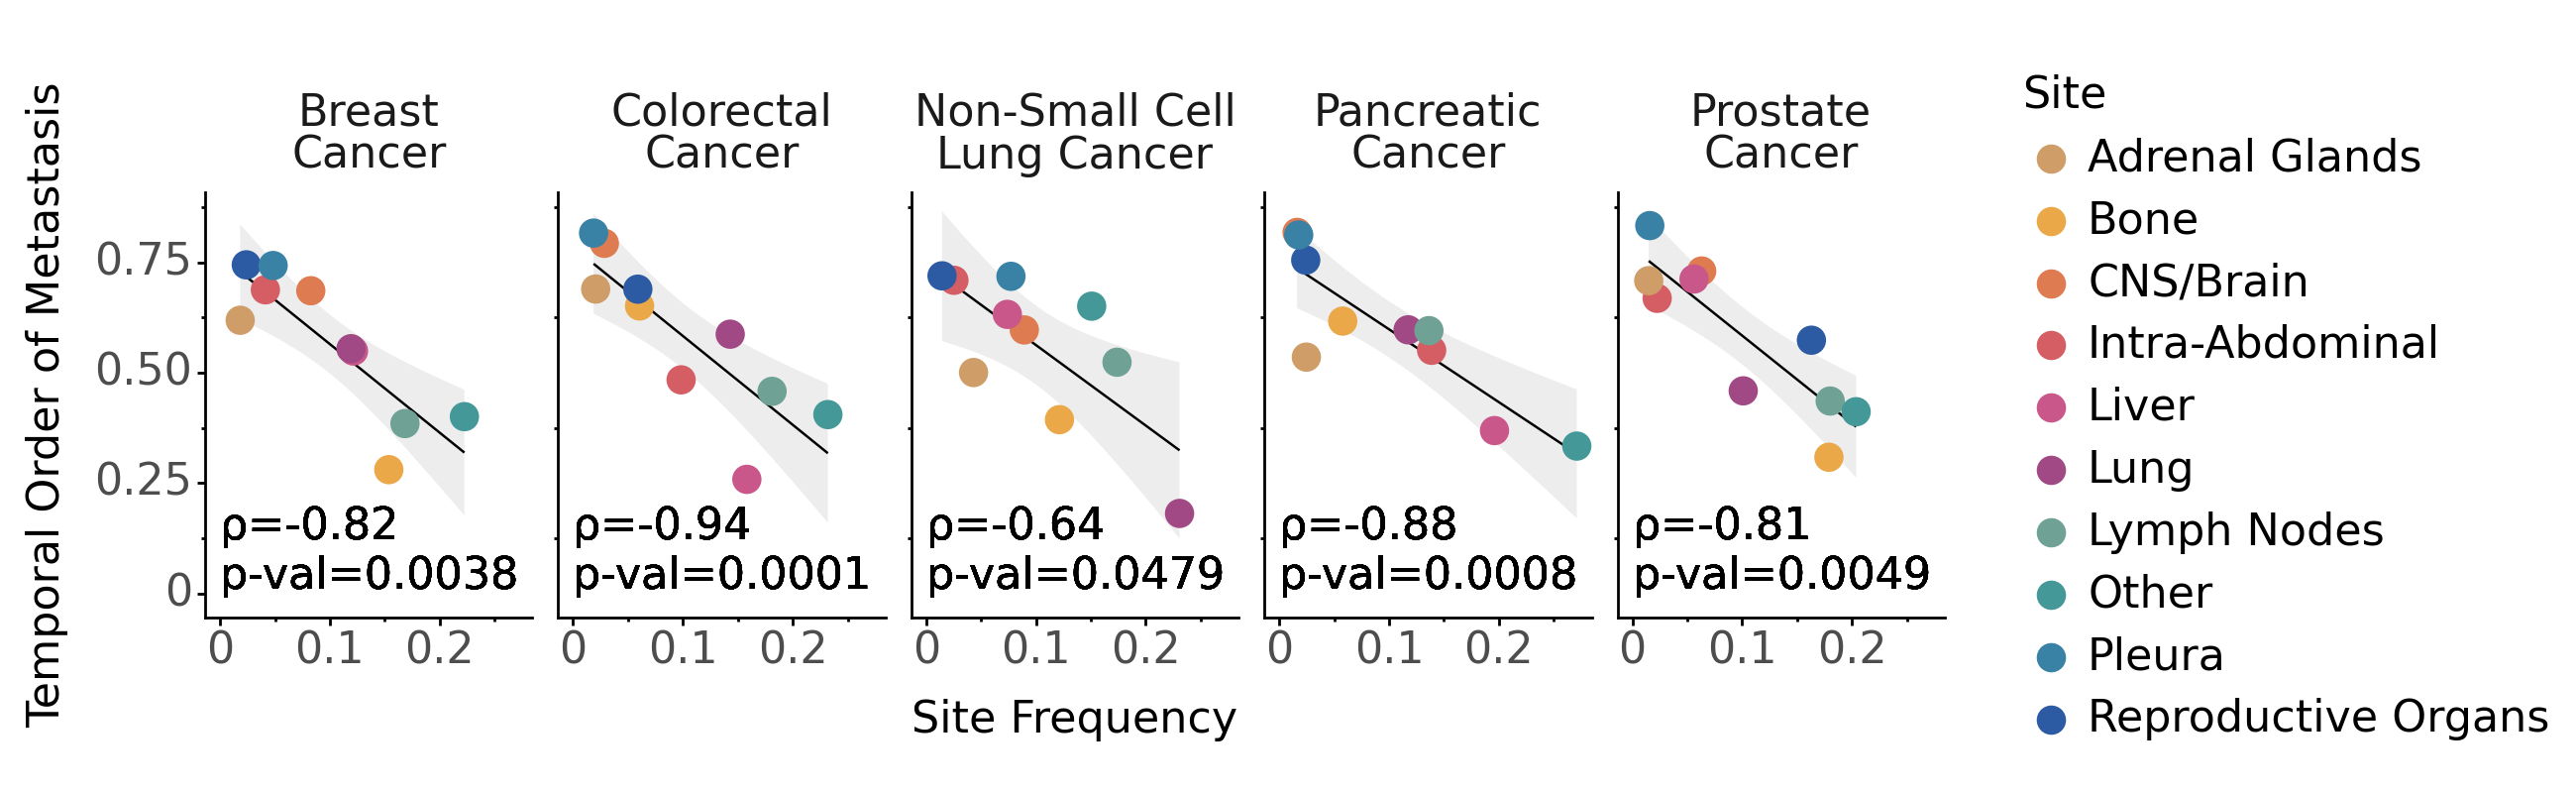

NameError: name 'repo_dir' is not defined

In [16]:

# Create a dataframe for plotting
plot_data = []
for cancer_type in site_positions:
    if cancer_type in freq_df.index:
        common_sites = set(freq_df.loc[cancer_type].index) & set(site_positions[cancer_type].keys())
        for site in common_sites:
            plot_data.append({
                'Cancer Type': cancer_type,
                'Site': site,
                'Frequency': freq_df.loc[cancer_type][site],
                'Position': site_positions[cancer_type][site]
            })

plot_df = pd.DataFrame(plot_data)
plot_df['Cancer Type'] = plot_df['Cancer Type'].astype('category') 

# Create faceted scatter plot using plotnine (Python's ggplot)
from plotnine import *

# Merge correlation results with plot data
plot_df = plot_df.merge(
    correlation_df[['Cancer Type', 'Spearman Correlation', 'P-value']], 
    on='Cancer Type'
).replace({'Cancer Type': {'Non-Small Cell Lung Cancer': 'Non-Small Cell\nLung Cancer',
                            'Breast Cancer': 'Breast\nCancer',
                            'Colorectal Cancer': 'Colorectal\nCancer',
                            'Prostate Cancer': 'Prostate\nCancer',
                            'Pancreatic Cancer': 'Pancreatic\nCancer',
                            }})

ggplot(plot_df, aes(x='Frequency', y='Position')) + \
    theme(text=element_text(family='Arial')) + \
    geom_point(aes(color='Site'), size=5, ) + \
    scale_color_brewer(type='qual', palette='Dark2') + \
    facet_grid('~Cancer Type') + \
    labs(
        x='Site Frequency',
        y='Temporal Order of Metastasis'
    ) + \
    theme_minimal() + \
    theme(
        figure_size=(16, 5),
        axis_title=element_text(size=16),
        strip_text=element_text(size=14),
        axis_text=element_text(size=14),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        axis_line=element_line(color='black'),
        axis_ticks=element_line(color='black'),
        legend_title=element_text(size=14),
        legend_text=element_text(size=12),
        legend_key_size=20
    ) + \
    scale_x_continuous(breaks=np.arange(0, max(plot_df['Frequency']+0.1), 0.1)) + \
    geom_text(
        aes(x=0, y=-0.01, 
            label="ρ=" + round(plot_df['Spearman Correlation'],2).astype(str) + 
                  "\np-val=" + round(plot_df['P-value'],4).astype(str)),
        size=14,
        ha='left',
        va='bottom',
        inherit_aes=False
    )

colors = ["#CF9D68", "#EAA849", "#DE7B50", "#D55D64", "#CA578A", "#A14985", "#6FA295", "#449898", "#3982A6", "#2C5BA3"]
plot = ggplot(plot_df, aes(x='Frequency', y='Position')) + \
    geom_smooth(method='lm', color='black', se=True, size=0.5, fill='lightgrey') + \
    theme_bw() + \
    theme(panel_background=element_rect(fill='white', color='white')) + \
    theme(plot_background=element_rect(fill='white', color='white')) + \
    theme(axis_text=element_text(color='black')) + \
    geom_point(aes(color='Site'), size=5, ) + \
    scale_color_manual(values=colors) + \
    facet_grid('~Cancer Type') + \
    labs(
        x='Site Frequency',
        y='Temporal Order of Metastasis'
    ) + \
    theme_minimal() + \
    theme(
        figure_size=(13, 4),
        axis_title=element_text(size=16),
        strip_text=element_text(size=16),
        axis_text=element_text(size=16),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        axis_line=element_line(color='black'),
        axis_ticks=element_line(color='black'),
        legend_title=element_text(size=16),
        legend_text=element_text(size=16),
        legend_key_size=20
    ) + \
    scale_x_continuous(breaks=np.arange(0, max(plot_df['Frequency']+0.1), 0.1)) + \
    geom_text(
        aes(x=0, y=-0.01, 
            label="ρ=" + round(plot_df['Spearman Correlation'],2).astype(str) + 
                  "\np-val=" + round(plot_df['P-value'],4).astype(str)),
        size=16,
        ha='left',
        va='bottom',
        inherit_aes=False
    )
print(plot)
plot.save(os.path.join(repo_dir, 'jupyter_notebooks', 'output_plots', 'metastasis_temporal_order_plot.svg'), dpi=100, facecolor='white')
